Final analytical notebook. Run after Notebook 03 and save in Google Colab.


# 04 | Full-History LightGBM and Final 28-Day Forecast

Notebook 03 selected recursive LightGBM after comparing it with both baselines. Here I fit the same model once more using all observed demand from d_1 to d_1941, then forecast d_1942 to d_1969. This covers 23 May to 19 June 2016.

This forecast is different from a backtest. Historical backtests can be scored because actual demand is known. The forward period contains predictions only, so it cannot yet be given an accuracy score.


## 1. Load the selected model

The first check confirms that Notebook 03 selected LightGBM. If the selection rule had failed, this notebook would stop instead of using the model automatically.


In [1]:
from pathlib import Path
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/MSc_Dissertation_Forecasting_Final")
except ImportError:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    PROJECT_ROOT = next(
        (path for path in candidates if (path / "src").is_dir()),
        Path.cwd().resolve(),
    )

if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError(
        f"Project source folder not found under {PROJECT_ROOT}."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.project_paths import ProjectPaths

PATHS = ProjectPaths(PROJECT_ROOT)
PATHS.ensure_output_directories()

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.forecast_governance import (
    SELECTED_MODEL,
    attach_historical_error_bands,
    build_category_forward_forecast,
    build_series_monitoring_profile,
)
from src.lightgbm_model import fit_predict_full_history, prepare_calendar

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

selection = pd.read_csv(PATHS.metrics / "model_selection.csv")
display(selection)
assert selection.loc[0, "selected_model"] == SELECTED_MODEL
assert bool(selection.loc[0, "lightgbm_selected"])
print(f"Selected model: {SELECTED_MODEL}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,selected_model,lightgbm_lower_rmsse_than_both_baselines,lightgbm_series_wins_vs_seasonal_naive,lightgbm_series_wins_vs_holt_winters,required_series_wins,lightgbm_selected,rationale
0,global_lightgbm_recursive,True,29,19,16,True,LightGBM passed the pre-specified complexity g...


Selected model: global_lightgbm_recursive


## 2. Check the training and forecast dates

Observed demand must end at d_1941, while the calendar must contain the following 28 dates. Calendar fields such as weekday and known events can be used because they do not reveal future sales. No actual demand after d_1941 is provided to the model.


In [2]:
panel = pd.read_csv(PATHS.processed / "m5_category_store_panel.csv", parse_dates=["date"])
calendar = prepare_calendar(PATHS.m5_file("calendar.csv"))
backtests = pd.read_csv(
    PATHS.powerbi / "fact_forecasts_all_models.csv",
    parse_dates=["origin_date", "forecast_date"],
)
metrics = pd.read_csv(PATHS.metrics / "forecast_metrics_all_models.csv")

future_calendar = calendar.loc[calendar["day_number"].between(1942, 1969)].copy()
checks = pd.DataFrame(
    {
        "check": [
            "Observed history ends at d_1941",
            "Thirty category-store series",
            "Future calendar contains 28 days",
            "Future calendar begins at d_1942",
            "Future calendar ends at d_1969",
        ],
        "passed": [
            panel["day_number"].max() == 1941,
            panel["series_id"].nunique() == 30,
            len(future_calendar) == 28,
            future_calendar["day_number"].min() == 1942,
            future_calendar["day_number"].max() == 1969,
        ],
    }
)
display(checks)
assert checks["passed"].all()
print(
    "Forward period:",
    future_calendar["date"].min().date(),
    "to",
    future_calendar["date"].max().date(),
)


,check,passed
0,Observed history ends at d_1941,True
1,Thirty category-store series,True
2,Future calendar contains 28 days,True
3,Future calendar begins at d_1942,True
4,Future calendar ends at d_1969,True


Forward period: 2016-05-23 to 2016-06-19


## 3. Fit on all observed history

I keep the same features and fixed LightGBM hyperparameters used in Notebook 03. Day 1 uses observed demand history. Later days use earlier predictions when actual lagged demand is unavailable.


In [3]:
forward, full_history_importance = fit_predict_full_history(panel, calendar)

assert len(forward) == 30 * 28
assert forward["forecast_type"].eq("Forward forecast").all()
assert forward["forecast_day"].min() == 1942
assert forward["forecast_day"].max() == 1969
assert forward["forecast"].notna().all()
assert forward["forecast"].ge(0).all()
assert not forward.duplicated(["series_id", "forecast_day"]).any()

print(f"Category-store forward forecasts: {len(forward):,}")
display(forward.head(10))


Category-store forward forecasts: 840


,forecast_type,model,origin_day,origin_date,series_id,category,store,state,forecast_day,forecast_date,horizon_day,horizon_band,forecast
0,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_CA_1,FOODS,CA_1,CA,1942,2016-05-23,1,D01-D07,"3,099.0420"
1,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_CA_2,FOODS,CA_2,CA,1942,2016-05-23,1,D01-D07,"2,912.7797"
2,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_CA_3,FOODS,CA_3,CA,1942,2016-05-23,1,D01-D07,"3,857.6945"
3,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_CA_4,FOODS,CA_4,CA,1942,2016-05-23,1,D01-D07,"1,870.4802"
4,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_TX_1,FOODS,TX_1,TX,1942,2016-05-23,1,D01-D07,"2,071.6769"
5,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_TX_2,FOODS,TX_2,TX,1942,2016-05-23,1,D01-D07,"2,669.4593"
6,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_TX_3,FOODS,TX_3,TX,1942,2016-05-23,1,D01-D07,"2,634.6951"
7,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_WI_1,FOODS,WI_1,WI,1942,2016-05-23,1,D01-D07,"2,547.5606"
8,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_WI_2,FOODS,WI_2,WI,1942,2016-05-23,1,D01-D07,"3,219.0024"
9,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS_WI_3,FOODS,WI_3,WI,1942,2016-05-23,1,D01-D07,"2,632.2216"


### Backtest and forward forecast are separate outputs

The historical backtests answer, "How accurately would the models have forecast known periods?" The forward run answers, "What does the selected model predict after the final observed day?" Only the backtests contain actual values and forecast errors.


In [4]:
selected_backtests = backtests.query("model == @SELECTED_MODEL")
forecast_type_check = pd.DataFrame(
    [
        {
            "forecast_type": "Backtest",
            "rows": len(selected_backtests),
            "series": selected_backtests["series_id"].nunique(),
            "periods": selected_backtests["fold_id"].nunique(),
            "actual_demand_available": selected_backtests["actual"].notna().all(),
            "purpose": "Historical evaluation and model selection",
        },
        {
            "forecast_type": "Forward forecast",
            "rows": len(forward),
            "series": forward["series_id"].nunique(),
            "periods": 1,
            "actual_demand_available": False,
            "purpose": "Future planning view after d_1941",
        },
    ]
)

assert len(selected_backtests) == 30 * 4 * 28
assert len(forward) == 30 * 28
display(forecast_type_check)


,forecast_type,rows,series,periods,actual_demand_available,purpose
0,Backtest,3360,30,4,True,Historical evaluation and model selection
1,Forward forecast,840,30,1,False,Future planning view after d_1941


## 4. Add historical error information

The future period cannot be scored because its actual demand is not part of the modelling data. I therefore use the earlier backtests to describe how each series performed historically.

The lower and upper values are descriptive empirical monitoring ranges based on the 10th and 90th percentiles of past residuals for each series and horizon band. Each range uses 28 residuals: seven forecast days from each of four folds. These are not prediction or confidence intervals, and their construction does not imply validated 80% future coverage.


In [5]:
residual_counts = selected_backtests.groupby(
    ["series_id", "horizon_band"], observed=True
).size()
assert residual_counts.eq(4 * 7).all()

monitoring = build_series_monitoring_profile(backtests, metrics)
forward = attach_historical_error_bands(forward, backtests, monitoring)
category_forward = build_category_forward_forecast(forward, backtests)

assert len(monitoring) == 30
assert len(category_forward) == 3 * 28
assert forward["historical_band_lower"].le(forward["historical_band_upper"]).all()
assert category_forward["historical_band_lower"].le(
    category_forward["historical_band_upper"]
).all()

display(monitoring.head(10))
display(category_forward.head(10))


,series_id,category,store,state,evaluated_forecasts,historical_absolute_error,historical_actual_units,historical_bias_units,historical_wape,historical_mean_rmsse,historical_max_fold_rmsse,evaluated_folds,monitoring_priority,threshold_basis
0,HOUSEHOLD_WI_2,HOUSEHOLD,WI_2,WI,112,"19,241.8806","132,818.0000",73.8304,0.1449,1.2312,1.8637,4,High review,Relative tercile of historical mean RMSSE
1,HOBBIES_CA_4,HOBBIES,CA_4,CA,112,"6,034.7947","42,292.0000",3.6422,0.1427,0.8857,0.9517,4,High review,Relative tercile of historical mean RMSSE
2,FOODS_CA_2,FOODS,CA_2,CA,112,"27,479.8001","322,275.0000",64.3377,0.0853,0.8458,1.4477,4,High review,Relative tercile of historical mean RMSSE
3,FOODS_WI_2,FOODS,WI_2,WI,112,"42,880.9262","437,517.0000",333.9660,0.0980,0.8312,0.9684,4,High review,Relative tercile of historical mean RMSSE
4,HOBBIES_WI_2,HOBBIES,WI_2,WI,112,"4,580.9457","32,192.0000",29.3563,0.1423,0.8217,0.9259,4,High review,Relative tercile of historical mean RMSSE
5,HOUSEHOLD_CA_4,HOUSEHOLD,CA_4,CA,112,"4,839.6472","59,953.0000",13.6846,0.0807,0.8156,0.9494,4,High review,Relative tercile of historical mean RMSSE
6,HOBBIES_TX_3,HOBBIES,TX_3,TX,112,"4,923.9491","44,616.0000",6.5264,0.1104,0.7800,0.8961,4,High review,Relative tercile of historical mean RMSSE
7,HOUSEHOLD_TX_3,HOUSEHOLD,TX_3,TX,112,"9,408.3157","109,538.0000",36.0047,0.0859,0.7189,0.8360,4,High review,Relative tercile of historical mean RMSSE
8,HOUSEHOLD_CA_2,HOUSEHOLD,CA_2,CA,112,"13,955.2263","122,502.0000",28.8486,0.1139,0.7125,0.9141,4,High review,Relative tercile of historical mean RMSSE
9,HOBBIES_CA_2,HOBBIES,CA_2,CA,112,"6,120.7734","46,176.0000",8.8763,0.1326,0.7040,0.8172,4,High review,Relative tercile of historical mean RMSSE


,forecast_type,model,origin_day,origin_date,category,forecast_day,forecast_date,horizon_day,horizon_band,category_forecast,historical_error_q10,historical_error_q90,historical_band_lower,historical_band_upper,uncertainty_method
0,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1942,2016-05-23,1,D01-D07,"27,514.6123","-1,149.7466","1,736.6995","26,364.8656","29,251.3118",Descriptive 10th-90th percentile category back...
1,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1943,2016-05-24,2,D01-D07,"24,642.0708","-1,149.7466","1,736.6995","23,492.3242","26,378.7703",Descriptive 10th-90th percentile category back...
2,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1944,2016-05-25,3,D01-D07,"23,821.9590","-1,149.7466","1,736.6995","22,672.2124","25,558.6585",Descriptive 10th-90th percentile category back...
3,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1945,2016-05-26,4,D01-D07,"23,534.9524","-1,149.7466","1,736.6995","22,385.2058","25,271.6519",Descriptive 10th-90th percentile category back...
4,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1946,2016-05-27,5,D01-D07,"26,898.0929","-1,149.7466","1,736.6995","25,748.3463","28,634.7925",Descriptive 10th-90th percentile category back...
5,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1947,2016-05-28,6,D01-D07,"32,348.5442","-1,149.7466","1,736.6995","31,198.7976","34,085.2437",Descriptive 10th-90th percentile category back...
6,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1948,2016-05-29,7,D01-D07,"34,414.8930","-1,149.7466","1,736.6995","33,265.1464","36,151.5925",Descriptive 10th-90th percentile category back...
7,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1949,2016-05-30,8,D08-D14,"30,313.1098","-1,066.7063","2,313.4917","29,246.4035","32,626.6016",Descriptive 10th-90th percentile category back...
8,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1950,2016-05-31,9,D08-D14,"25,749.7381","-1,066.7063","2,313.4917","24,683.0318","28,063.2298",Descriptive 10th-90th percentile category back...
9,Forward forecast,global_lightgbm_recursive,1941,2016-05-22,FOODS,1951,2016-06-01,10,D08-D14,"26,868.6231","-1,066.7063","2,313.4917","25,801.9168","29,182.1149",Descriptive 10th-90th percentile category back...


## 5. Calculate category totals

For each day, I sum the ten store forecasts within each category. This produces a simpler category view while keeping the 30 category-store forecasts available for further detail.


,category,forecast_28_day_total,mean_daily_forecast,peak_daily_forecast
0,FOODS,"880,120.8893","31,432.8889","42,571.1983"
2,HOUSEHOLD,"297,336.6522","10,619.1662","13,521.4737"
1,HOBBIES,"117,425.7023","4,193.7751","5,226.0996"


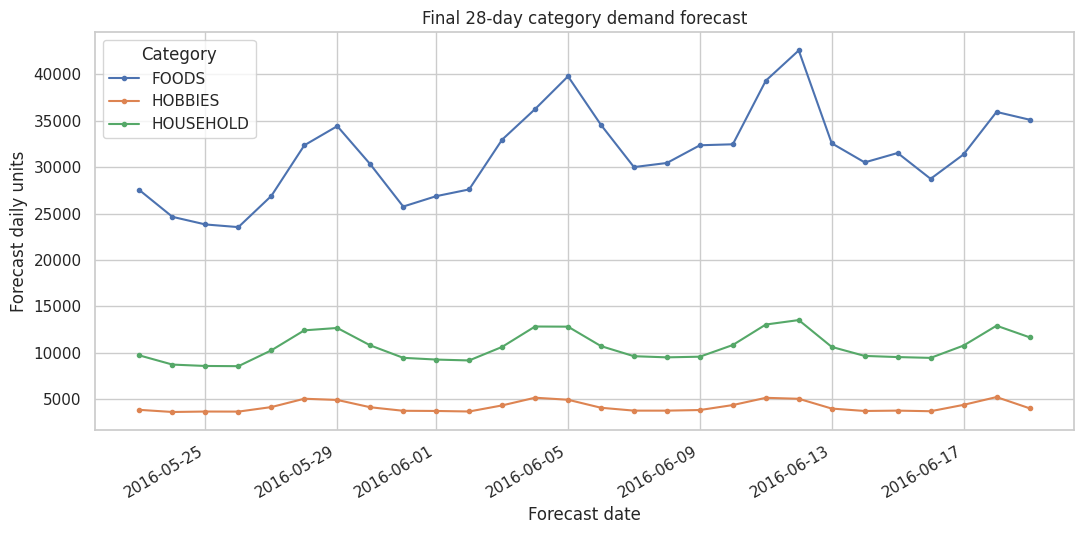

In [6]:
category_summary = (
    category_forward.groupby("category", observed=True)
    .agg(
        forecast_28_day_total=("category_forecast", "sum"),
        mean_daily_forecast=("category_forecast", "mean"),
        peak_daily_forecast=("category_forecast", "max"),
    )
    .reset_index()
    .sort_values("forecast_28_day_total", ascending=False)
)
display(category_summary)

fig, ax = plt.subplots(figsize=(11, 5.5))
for category, frame in category_forward.groupby("category", observed=True):
    frame = frame.sort_values("forecast_date")
    dates = pd.to_datetime(frame["forecast_date"])
    ax.plot(dates, frame["category_forecast"], marker="o", markersize=3, label=category)
ax.set(
    title="Final 28-day category demand forecast",
    xlabel="Forecast date",
    ylabel="Forecast daily units",
)
ax.legend(title="Category")
fig.autofmt_xdate()
fig.tight_layout()
display(fig)
plt.close(fig)


## 6. Save the forward forecast

The forward forecast, category totals and monitoring table are saved separately from the historical evaluation results. Notebook 05 prepares these files for Power BI.


In [7]:
forward.to_csv(PATHS.powerbi / "fact_forward_forecast.csv", index=False)
category_forward.to_csv(
    PATHS.powerbi / "fact_category_forward_forecast.csv", index=False
)
monitoring.to_csv(PATHS.powerbi / "fact_forecast_monitoring.csv", index=False)
full_history_importance.to_csv(
    PATHS.metrics / "full_history_lightgbm_feature_importance.csv", index=False
)

forward_manifest = pd.DataFrame(
    [
        {"output": "fact_forward_forecast.csv", "rows": len(forward)},
        {"output": "fact_category_forward_forecast.csv", "rows": len(category_forward)},
        {"output": "fact_forecast_monitoring.csv", "rows": len(monitoring)},
    ]
)
forward_manifest.to_csv(PATHS.powerbi / "forward_forecast_manifest.csv", index=False)
display(forward_manifest)


,output,rows
0,fact_forward_forecast.csv,840
1,fact_category_forward_forecast.csv,84
2,fact_forecast_monitoring.csv,30


## 7. What this forecast means

This notebook produces the final 28-day forecast, but it does not provide new evidence that LightGBM is accurate. Model selection still depends on the four historical tests in Notebook 03.

The outputs can support review of expected category-store demand, category totals and historically less reliable series. They do not calculate SKU quantities, create purchase orders, optimise inventory or recommend supplier actions. The dates are forward-looking relative to the M5 cutoff in 2016, not a live forecast for 2026.


In [8]:
assert forward_manifest["rows"].tolist() == [840, 84, 30]
print("NOTEBOOK 04 COMPLETED SUCCESSFULLY")


NOTEBOOK 04 COMPLETED SUCCESSFULLY
